In [35]:
#Import essential libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [36]:
#Reading data of ecommerce sales

data = pd.read_csv('ecommerce_sales_data.csv')
data.head()

,Order ID,Date,Product Name,Category,Quantity,Price,Region,Customer ID,Customer Segment,Total Sales
0,1,2023-01-01,Tablet,Electronics,3,2500,East,1819,Individual,7500
1,2,2023-01-02,Camera,Electronics,1,1000,North,1220,Individual,1000
2,3,2023-01-03,Headphones,Electronics,4,2500,West,1819,Corporate,10000
3,4,2023-01-04,Camera,Electronics,1,500,South,1419,Corporate,500
4,5,2023-01-05,Camera,Electronics,1,1000,South,1123,Individual,1000


In [37]:
#Delete unusable columns

data = data.drop(data[['Customer ID', 'Order ID']], axis=1)

In [38]:
data.head()

,Date,Product Name,Category,Quantity,Price,Region,Customer Segment,Total Sales
0,2023-01-01,Tablet,Electronics,3,2500,East,Individual,7500
1,2023-01-02,Camera,Electronics,1,1000,North,Individual,1000
2,2023-01-03,Headphones,Electronics,4,2500,West,Corporate,10000
3,2023-01-04,Camera,Electronics,1,500,South,Corporate,500
4,2023-01-05,Camera,Electronics,1,1000,South,Individual,1000


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              500 non-null    object
 1   Product Name      500 non-null    object
 2   Category          500 non-null    object
 3   Quantity          500 non-null    int64 
 4   Price             500 non-null    int64 
 5   Region            500 non-null    object
 6   Customer Segment  500 non-null    object
 7   Total Sales       500 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 31.4+ KB


In [40]:
#Convert the 'Date' column to the proper format

data['Date'] = pd.to_datetime(data['Date'], format="%Y-%m-%d")

In [41]:
data['Date']

0     2023-01-01
1     2023-01-02
2     2023-01-03
3     2023-01-04
4     2023-01-05
         ...    
495   2024-05-10
496   2024-05-11
497   2024-05-12
498   2024-05-13
499   2024-05-14
Name: Date, Length: 500, dtype: datetime64[ns]

In [42]:
data.columns

Index(['Date', 'Product Name', 'Category', 'Quantity', 'Price', 'Region',
       'Customer Segment', 'Total Sales'],
      dtype='object')

Analyse des données 

In [43]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,500,2023-09-07 12:00:00,2023-01-01 00:00:00,2023-05-05 18:00:00,2023-09-07 12:00:00,2024-01-10 06:00:00,2024-05-14 00:00:00,NaN
Quantity,500.0,2.442,1.0,1.0,2.0,3.0,4.0,1.103209
Price,500.0,1141.0,200.0,500.0,1000.0,1500.0,2500.0,819.122043
Total Sales,500.0,2780.0,200.0,800.0,2000.0,4500.0,10000.0,2518.301747


In [44]:
#Total revenue
total_revenue = data['Total Sales'].sum()
print(f"Total revenue is : {total_revenue}$")

Total revenue is : 1390000$


In [45]:
#Calculation of the monthly sales trend
data['Month'] = data['Date'].dt.to_period('M')

#monthly sales
monthly_sales = data.groupby('Month')['Total Sales'].sum().reset_index()

print(monthly_sales)

      Month  Total Sales
0   2023-01        74100
1   2023-02        64800
2   2023-03       110000
3   2023-04        99300
4   2023-05        95600
5   2023-06        92800
6   2023-07        73500
7   2023-08        68700
8   2023-09        71000
9   2023-10        78400
10  2023-11        95100
11  2023-12        90900
12  2024-01        91100
13  2024-02        94100
14  2024-03        76100
15  2024-04        62900
16  2024-05        51600


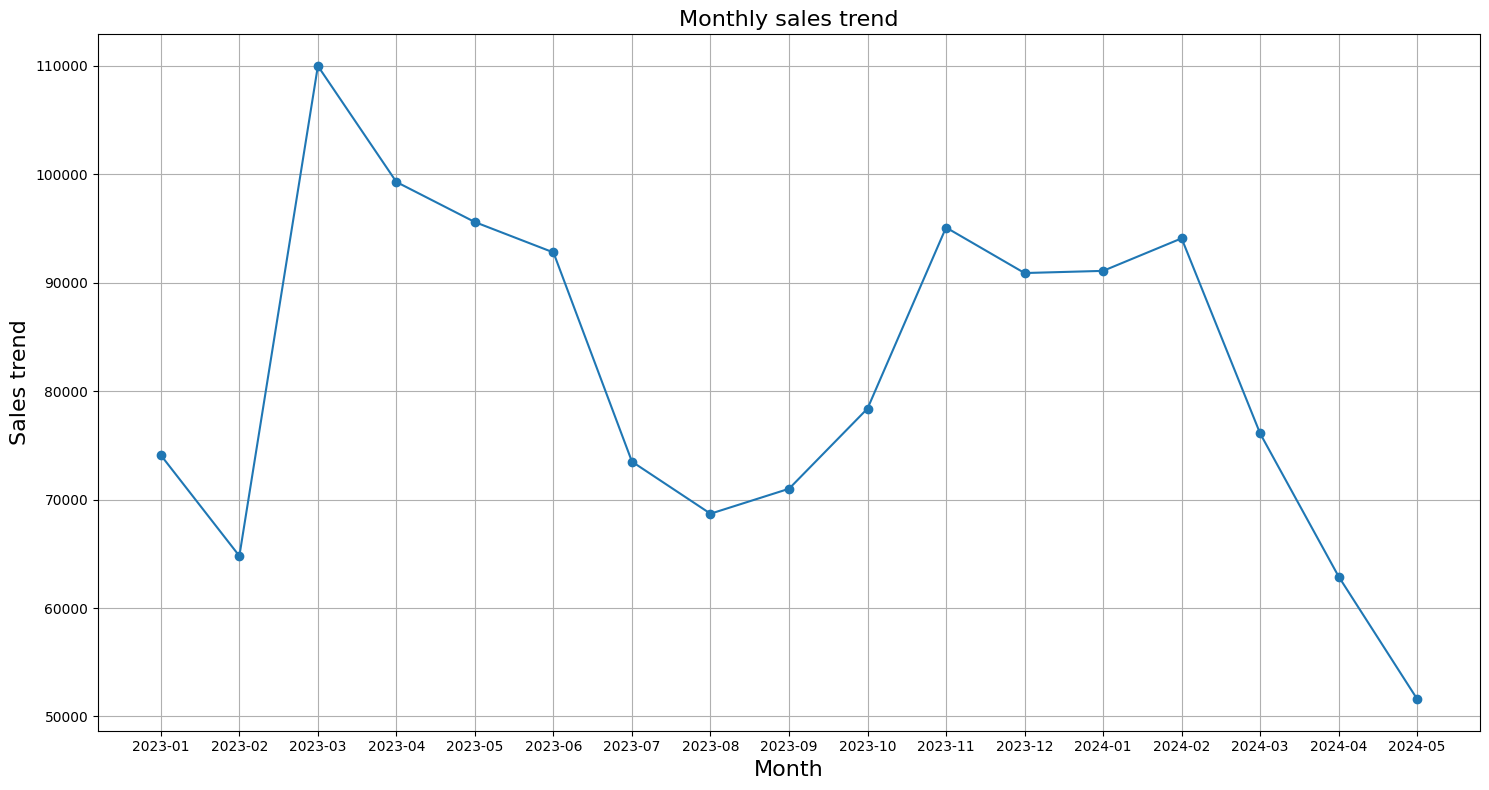

In [46]:
plt.figure(figsize=(15,8))
plt.plot(monthly_sales['Month'].astype(str), monthly_sales['Total Sales'], marker="o")
plt.title('Monthly sales trend', fontsize=16)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Sales trend', fontsize=16)
#plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Products analysis

In [47]:
#Most sales products
most_sale = data.groupby('Product Name')['Quantity'].sum().reset_index()

most_sale = most_sale.sort_values(by='Quantity', ascending=False)

print(most_sale)

  Product Name  Quantity
5       Tablet       242
2       Laptop       216
4   Smartwatch       201
0       Camera       191
1   Headphones       190
3   Smartphone       181


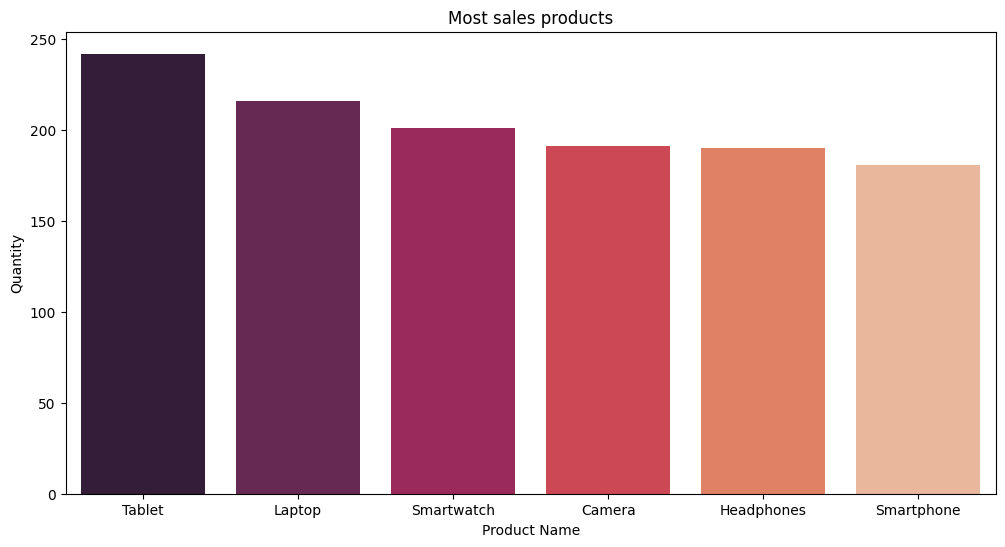

In [48]:
plt.figure(figsize=(12,6))
sns.barplot(data=most_sale, x="Product Name", y="Quantity", palette='rocket')
plt.title("Most sales products")
plt.show()

In [49]:
# The products that generate the most revenue
most_revenu = data.groupby('Product Name')['Total Sales'].sum().reset_index()

# Sort by descending revenue
most_revenu = most_revenu.sort_values(by='Total Sales', ascending=False)

# top 5 products
top_products = most_revenu.head(5)

explode = [0.1] + [0] * (len(top_products) - 1) 

print(most_revenu)

  Product Name  Total Sales
5       Tablet       269400
4   Smartwatch       251600
2       Laptop       235400
1   Headphones       216200
0       Camera       214100
3   Smartphone       203300


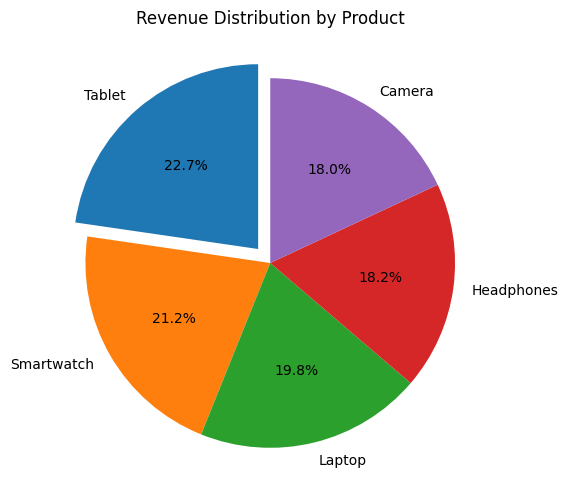

In [50]:
plt.figure(figsize=(8, 6))
plt.pie(
    x=top_products['Total Sales'],
    labels=top_products['Product Name'],
    explode=explode,
    autopct='%1.1f%%',  
    startangle=90,
    colors=plt.cm.tab10.colors[:5] 
)
plt.title('Revenue Distribution by Product')
plt.show()

Analysis by region

In [51]:
data['Region'].value_counts()

Region
South    134
West     127
North    123
East     116
Name: count, dtype: int64

In [52]:
# Distribution of revenue by region

reg_sales = data.groupby('Region')['Total Sales'].sum().reset_index()

reg_sales = reg_sales.sort_values(by='Total Sales', ascending=False)

print(reg_sales)

  Region  Total Sales
2  South       388800
3   West       378500
0   East       311400
1  North       311300


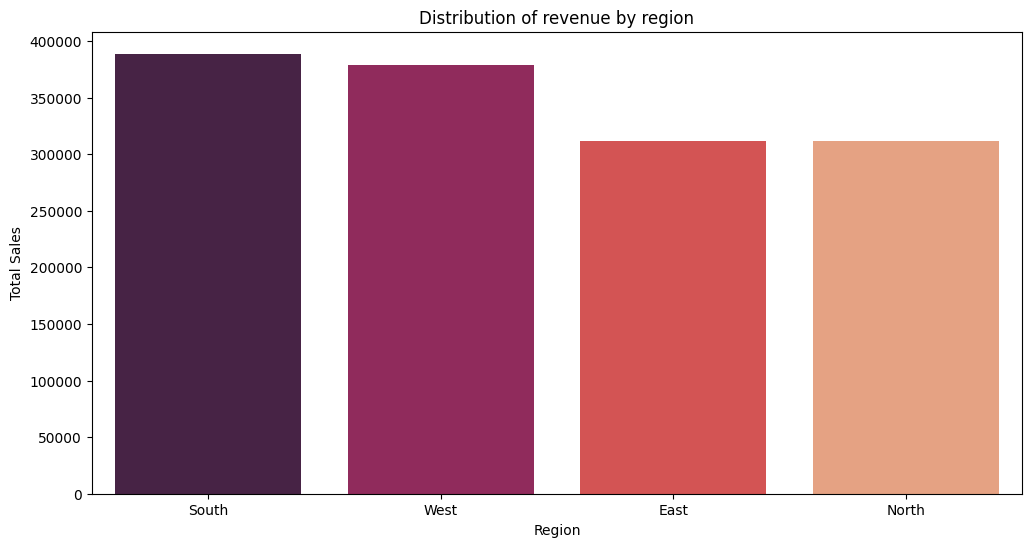

In [62]:
plt.figure(figsize=(12,6))
sns.barplot(data=reg_sales, x="Region", y="Total Sales", palette='rocket')
plt.title('Distribution of revenue by region')
plt.show()

Regions with the low revenue

In [54]:
# Total revenue
total_revenue = data['Total Sales'].sum()

# Add a column representing the sales proportion by region
reg_sales['Revenue Share (%)'] = (reg_sales['Total Sales'] / total_revenue) * 100

print(reg_sales)


  Region  Total Sales  Revenue Share (%)
2  South       388800          27.971223
3   West       378500          27.230216
0   East       311400          22.402878
1  North       311300          22.395683


In [63]:
average_revenue_share = reg_sales['Revenue Share (%)'].mean()

# Identify underperforming regions (below average)
underperforming_regions = reg_sales[reg_sales['Revenue Share (%)'] < average_revenue_share]

print("Runderperforming regions :")
print(underperforming_regions)


Runderperforming regions :
  Region  Total Sales  Revenue Share (%)
0   East       311400          22.402878
1  North       311300          22.395683


Clients analysis

In [56]:
data.head(2)

,Date,Product Name,Category,Quantity,Price,Region,Customer Segment,Total Sales,Month
0,2023-01-01,Tablet,Electronics,3,2500,East,Individual,7500,2023-01
1,2023-01-02,Camera,Electronics,1,1000,North,Individual,1000,2023-01


In [57]:
data['Customer Segment'].value_counts()

Customer Segment
Individual    301
Corporate     199
Name: count, dtype: int64

In [58]:
# Distribution of revenue by customer segments

segm_sales = data.groupby('Customer Segment')['Total Sales'].sum().reset_index()

segm_sales = segm_sales.sort_values(by='Total Sales', ascending=False)

explode = [0.1] + [0] * (len(segm_sales) - 1)

print(segm_sales)

  Customer Segment  Total Sales
1       Individual       820500
0        Corporate       569500


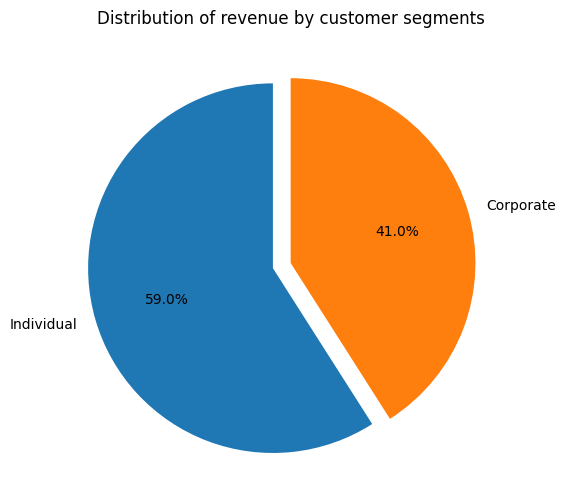

In [64]:
plt.figure(figsize=(8,6))
plt.pie(x=segm_sales['Total Sales'],
        labels=segm_sales['Customer Segment'],
        explode=explode,
        autopct='%1.1f%%', 
        startangle=90,
        colors=plt.cm.tab10.colors[:5]
)
plt.title("Distribution of revenue by customer segments")
plt.show()

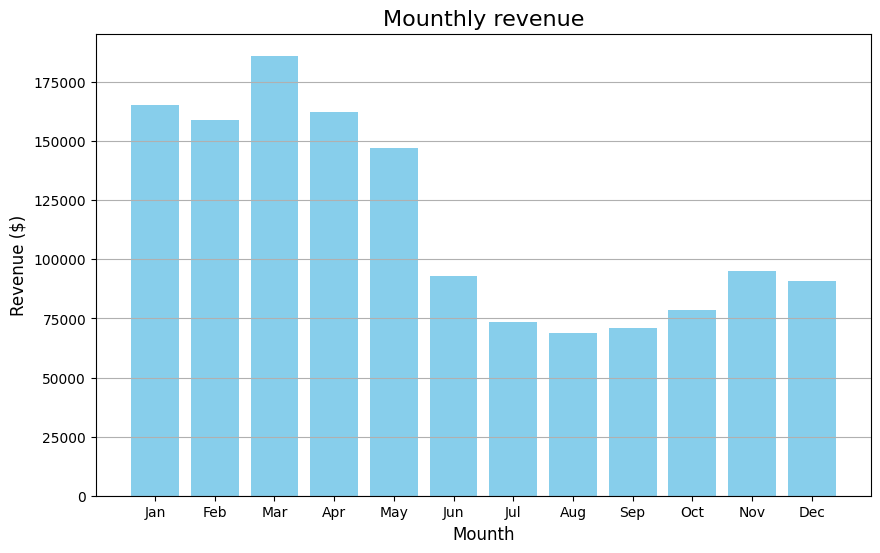

Key mounths with sales peaks :
   Month  Total Sales
0      1       165200
1      2       158900
2      3       186100
3      4       162200
4      5       147200


In [65]:
# Add Mounth column
data['Month'] = data['Date'].dt.month

# Calculating mounthly revenues
monthly_sales = data.groupby('Month')['Total Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(monthly_sales['Month'], monthly_sales['Total Sales'], color='skyblue')
plt.title('Mounthly revenue', fontsize=16)
plt.xlabel('Mounth', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y')
plt.show()

# Identify the key months
print("Key mounths with sales peaks :")
print(monthly_sales[monthly_sales['Total Sales'] > monthly_sales['Total Sales'].mean()])
